# V1-S07 — Handlabel Sample Notebook

Drives the stratified sample for the 500-abstract hand-labeling pool.
Reads `papers.duckdb` and `topics.parquet`; writes
`data/v1/handlabel_sample.parquet` + sidecar JSON.

Plan: `plans/2026-05-22-v1-s07-epistemic-prep.md` §B.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import duckdb
from omegaconf import OmegaConf

# Repo root sniffing — notebook runs from notebooks/, code lives one dir up.
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

from scifield.epistemic.sampling import SamplingConfig, stratified_sample  # noqa: E402
from scifield.repro import record_run  # noqa: E402

In [2]:
cfg = OmegaConf.load(repo_root / "conf" / "epistemic" / "v1.yaml")
sample_path = repo_root / cfg.output.sample_path
duckdb_path = repo_root / cfg.input.duckdb_path
topics_parquet = repo_root / cfg.input.topics_parquet
print(f"duckdb={duckdb_path}\ntopics={topics_parquet}\nout={sample_path}")

duckdb=/Users/samersalman/Desktop/SciField/data/v1/papers.duckdb
topics=/Users/samersalman/Desktop/SciField/data/v1/topics.parquet
out=/Users/samersalman/Desktop/SciField/data/v1/handlabel_sample.parquet


In [3]:
sampling_cfg = SamplingConfig(
    duckdb_path=duckdb_path,
    topics_parquet=topics_parquet,
    n_sample=int(cfg.sampling.n_sample),
    seed=int(cfg.sampling.seed),
    eras=tuple(cfg.sampling.eras),
    topic_coverage_min=int(cfg.sampling.topic_coverage_min),
)
con = duckdb.connect(str(duckdb_path))  # RW: stratified_sample creates papers_distinct view
df = stratified_sample(con, sampling_cfg)
con.close()
print(
    f"n_rows={len(df)}, "
    f"n_cells={df.groupby(['journal', 'era']).ngroups}, "
    f"n_topics={df['topic_id'].nunique(dropna=True)}"
)
df.head(3)

n_rows=500, n_cells=40, n_topics=113


,pmid,journal,year,era,topic_id,title,abstract
0,7491545,surgery,1995,pre2000,20,Large cystic/solid thyroid nodules: a potentia...,False-negative fine-needle aspiration (FNA) bi...
1,7492277,jama_surg,1995,pre2000,4,Polymyxin B prevents increased sympathetic act...,To determine the effects of polymyxin B sulfat...
2,7538405,j_am_coll_surg,1995,pre2000,-1,Patterns of care for carcinoma of the prostate...,The annual incidence of carcinoma of the prost...


In [4]:
cell_counts = df.groupby(["journal", "era"]).size().unstack(fill_value=0)
cell_counts

era,2000-2009,2010-2019,2020+,pre2000
journal,,,,
ann_surg,12,17,15,5
arthroscopy,13,19,17,4
br_j_surg,11,12,5,8
clin_orthop_relat_res,25,19,6,12
j_am_coll_surg,8,11,6,3
j_arthroplasty,13,27,23,4
j_bone_joint_surg_am,15,17,9,4
jama_surg,9,8,4,5
spine,31,29,12,11


In [5]:
df["era"].value_counts().reindex(list(sampling_cfg.eras))

era
pre2000       63
2000-2009    149
2010-2019    176
2020+        112
Name: count, dtype: int64

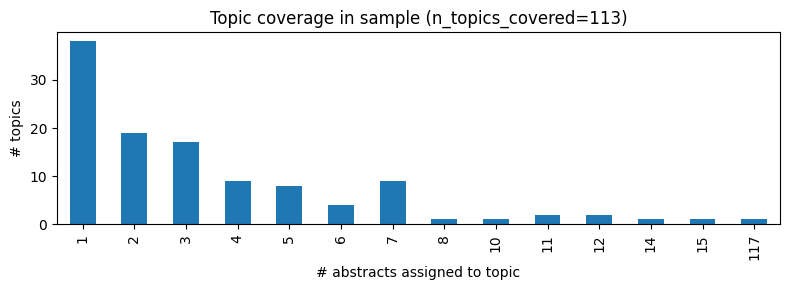

In [6]:
import matplotlib.pyplot as plt

topic_counts = df["topic_id"].value_counts(dropna=True)
ax = topic_counts.value_counts().sort_index().plot(kind="bar", figsize=(8, 3))
ax.set_xlabel("# abstracts assigned to topic")
ax.set_ylabel("# topics")
ax.set_title(f"Topic coverage in sample (n_topics_covered={len(topic_counts)})")
plt.tight_layout()
plt.show()

## Persist

Write the parquet + the sidecar `.run.json` so the next session can
reproduce this sample exactly.

In [7]:
import pyarrow as pa
import pyarrow.parquet as pq

sample_path.parent.mkdir(parents=True, exist_ok=True)
pq.write_table(pa.Table.from_pandas(df), sample_path)
record_run(
    artifact_path=sample_path,
    inputs={"papers_duckdb": duckdb_path, "topics_parquet": topics_parquet},
    config={
        "n_sample": sampling_cfg.n_sample,
        "seed": sampling_cfg.seed,
        "eras": list(sampling_cfg.eras),
        "topic_coverage_min": sampling_cfg.topic_coverage_min,
    },
)
print(f"wrote {sample_path}")

wrote /Users/samersalman/Desktop/SciField/data/v1/handlabel_sample.parquet


## Next steps

- `scifield epistemic export-labels --rater <name>` → produces a per-rater
  .xlsx with data-validated enum cells.
- `scifield epistemic pilot --n 50` → runs the 50-abstract Claude Code
  pilot (V1-S07 step D).
- V1-S08 will execute the full 500-abstract handlabeling sprint;
  this notebook does NOT proceed past sampling.